# Assignment 3 - M&Ms-2 Segmentation

***RDGY41710 - AI For Medical Image Analysis - 2024/25 Summer***

> - **Group Memebers:** Martha Rotter, Binhan Xiao, Devaharish Srikannan, William O'Brien, Yu Du
> - **Last Update:** July 28<sup>th</sup>, 2025

**Keywords:** **M&Ms-2**, **MRI Segmentation**, **SegFormer**

According to the assignment guidelines, segmented cardiac MRIs can be obtained from the [*MICCAI 2021*](https://www.ub.edu/mnms-2/) website. Additionally, I have stored the preprocessed data files on [my Google Drive](https://drive.google.com/drive/folders/14wLNTkQ8gKKYO0PJa3FQj5b5dPwgpehD?usp=sharing) (I compressed them as a [`.7z` file](https://drive.google.com/file/d/1RCwUzfSP3UdZRMFibvcx0aZUiUqmLQvr/view?usp=share_link), which should be easier to download) for reference.

In this assignment, we adopted the following pipeline to address the task of classifying at least two pathologies based on recognition from the M&Ms-2 cardiac MRI dataset:

![pipline](./pipeline.jpg)



The required runtime environment can be set up using the following commands:
```bash
conda create -n rv-segmentation python=3.10 -y
conda activate rv-segmentation
pip install numpy pandas matplotlib nibabel SimpleITK datasets evaluate accelerate torchvision transformers scikit-learn 
```

In [ ]:
# Import necessary packages
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nibabel as nib
from tqdm import tqdm

import evaluate
import accelerate

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

from torchvision import transforms

from transformers import SegformerForSemanticSegmentation, SegformerFeatureExtractor
from transformers import ViTForImageClassification, ViTFeatureExtractor, Trainer, TrainingArguments

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

/opt/miniconda3/envs/rv-segmentation/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Set the random number seed for easy reproduction
random.seed(2025)

# Set the device (MPS / CUDA / CPU)
# Note: it will report an error under Apple's Metal hardware when performing the back forword
# device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')
print(f'Using device: {device}')

Using device: mps


---

## Organizing the Data

The official documentation states that the cohort consists of 360 patients with various right and left ventricle pathologies, as well as healthy subjects (*M&Ms-2 Challenge*, n.d.). In fact, within the dataset, the `dataset` folder contains the original data, with cases numbered from 001 to 360 (360 total cases from multiple centers, using different scanners and pathology types). The `filtered` folder includes data that has undergone preprocessing steps such as N4 bias field correction, resampling, and cropping (Linardos et al., 2022), and retains only 280 cases that passed quality control criteria.

Based on this information, we decided to directly use the `filtered` folder as our final dataset.[^1] The full data directory structure is as follows:

[^1]: See [my Google Drive](https://drive.google.com/drive/folders/1uIT2LaAuEy6eD2VbZmOgidy7bxiEPTqu?usp=share_link) for examples of data visualization.

```bash
cardiac segmentation/
├── dataset/
│   ├── 001/
│   │   ├── 001_LA_CINE.nii.gz      # shape (256, 256, 1, 25): (Width pixels, High pixels, Number of dynamic images, Dynamic image frame rate)
│   │   ├── 001_LA_ED_gt.nii.gz     # shape (256, 256, 1): (Width pixels, High pixels, Number of images)
│   │   ├── 001_LA_ED.nii.gz        # shpae (256, 256, 1): ..
│   │   ├── 001_LA_ES_gt.nii.gz     # shape (256, 256, 1): ..
│   │   ├── 001_LA_ES.nii.gz        # shape (256, 256, 1): ..
│   │   ├── 001_SA_CINE.nii.gz      # shape (256, 256, 12, 25): (Width pixels, High pixels, Number of dynamic images, Dynamic image frame rate)
│   │   ├── 001_SA_ED_gt.nii.gz     # shape (256, 256, 12): (Width pixels, High pixels, Number of images)
│   │   ├── 001_SA_ED.nii.gz        # shape (256, 256, 12): ..
│   │   ├── 001_SA_ES_gt.nii.gz     # shape (256, 256, 12): ..
│   │   └── 001_SA_ES.nii.gz        # shape (256, 256, 12): ..
│   ...
│   └── 360/
│       ├── 360_LA_CINE.nii.gz
│       ...
│       └── 360_SA_ES.nii.gz
├── filtered/
│   ├── 001/
│   │   ├── 001_LA_CINE.nii.gz
│   │   ...
│   │   └── 001_SA_ES.nii.gz
│   ...
│   └── 280/
│       ├── 280_LA_CINE.nii.gz
│       ...
│       └── 280_SA_ES.nii.gz
└── dataset_information.csv
```

Next, we will create a folder named `compiled` inside the cardiac segmentation directory and convert the 3D static MRIs into 2D static MRIs.

In [ ]:
# ========= Reading and Transforming Data =========
# Define source data and target paths
root_dir = "./cardiac segmentation/filtered"
output_images_dir = "./cardiac segmentation/compiled/images"
output_labels_dir = "./cardiac segmentation/compiled/labels"

# Create the output directory if it does not exist
os.makedirs(output_images_dir, exist_ok=True)
os.makedirs(output_labels_dir, exist_ok=True)

# Determine whether it is an invalid label (all black or all white)
def is_invalid_mask(slice_2d):
    unique_vals = np.unique(slice_2d)
    return len(unique_vals) == 1 and (unique_vals[0] == 0 or unique_vals[0] == 1 or unique_vals[0] == 255)

# Store skipped slice logs
skipped_pairs = []

# Traverse each sample directory
for patient_id in tqdm(sorted(os.listdir(root_dir))):

    patient_path = os.path.join(root_dir, patient_id)
    if not os.path.isdir(patient_path):
        continue

    all_files = {f.replace(".nii.gz", ""): os.path.join(patient_path, f)
        for f in os.listdir(patient_path) if f.endswith(".nii.gz") and not f.endswith("_CINE.nii.gz")}

    for name, file_path in all_files.items():
        is_label = name.endswith("_gt")

        # Remove "_gt"
        if is_label:
            base_name = name[:-3]
            image_name = base_name
            label_name = name

        # Only process labels to avoid repeated traversal of the original image
        else:
            continue

        # Path check: make sure the original image exists
        if image_name not in all_files:
            print(f"[Warning] Original image missing: {image_name}")
            continue

        image_data = nib.load(all_files[image_name]).get_fdata()
        label_data = nib.load(all_files[label_name]).get_fdata()
        affine = nib.load(all_files[image_name]).affine

        if image_data.ndim == 3 and label_data.ndim == 3:
            for i in range(label_data.shape[2]):
                label_slice = label_data[:, :, i]
                image_slice = image_data[:, :, i]

                if is_invalid_mask(label_slice):
                    skipped_pairs.append(f"{image_name}_{i+1:03d}")
                    continue

                # Save the original image
                img_outfile = f"{image_name}_{i+1:03d}.nii.gz"
                nib.save(nib.Nifti1Image(image_slice.astype(np.float32), affine),
                         os.path.join(output_images_dir, img_outfile))

                # Save label image
                label_outfile = f"{label_name}_{i+1:03d}.nii.gz"
                nib.save(nib.Nifti1Image(label_slice.astype(np.float32), affine),
                         os.path.join(output_labels_dir, label_outfile))

        elif image_data.ndim == 2 and label_data.ndim == 2:
            if is_invalid_mask(label_data):
                skipped_pairs.append(f"{image_name}_001")
                continue

            nib.save(nib.Nifti1Image(image_data.astype(np.float32), affine),
                     os.path.join(output_images_dir, f"{image_name}_001.nii.gz"))

            nib.save(nib.Nifti1Image(label_data.astype(np.float32), affine),
                     os.path.join(output_labels_dir, f"{label_name}_001.nii.gz"))

# Print skipped content
print("\n[INFO] The following image and label pairs are skipped (label is all black or all white): ")
for item in skipped_pairs:
    print(f"  - {item}") 
print(f"\nA total of {len(skipped_pairs)} pairs of images and labels were skipped.")       

## MRIs Segmentation

Among segmentation models, we considered SegFormer model for the segmentation, which can keep consistent in archtecture with the classification model, since we decided to use ViT as the classification model at next stage. We used the SegFormer model developed by NVIDIA (integrated by [Hugging Face](https://huggingface.co/docs/transformers/model_doc/segformer)). NVIDIA provided multiple pre-trained version for selection and the model can be compatible for standard PyTorch API very well.

In [6]:
# ========= Loading Data and Model =========
# Define paths and parameters
image_dir = "./cardiac segmentation/compiled/images"
label_dir = "./cardiac segmentation/compiled/labels"
img_size = 256
batch_size = 4
num_classes = 4
num_epochs = 10
learning_rate = 5e-5

# Load a feature extractor (with standard normalization)
feature_extractor = SegformerFeatureExtractor(do_resize=True, size=img_size, resample=3, do_normalize=True)

# Define dataset subclasses based on actual data conditions
class NiiSegDataset(Dataset):

    def __init__(self, image_paths, label_paths):
        self.image_paths = image_paths
        self.label_paths = label_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = nib.load(self.image_paths[idx]).get_fdata().astype(np.float32)

        # Min-Max normalize to [0, 255]
        img = np.clip(img, 0, np.percentile(img, 99))                   # Clip outliers
        img = (img - img.min()) / (img.max() - img.min() + 1e-5) * 255.0
        img = img.astype(np.uint8)

        # Process as 256x256 grayscale image
        img = np.expand_dims(img, axis=2)                               # shape: (H, W, 1)
        img = np.repeat(img, 3, axis=2)                                 # (H, W, 3) -> fake RGB
        
        processed = feature_extractor(images=img, return_tensors="pt")
        pixel_values = processed['pixel_values'].squeeze().contiguous() # shape: (3, H, W)

        label = nib.load(self.label_paths[idx]).get_fdata().astype(np.int64)

        label = torch.tensor(label).unsqueeze(0).unsqueeze(0).float()
        label = F.interpolate(label, size=(img_size, img_size), mode='nearest')
        label = label.squeeze().long().contiguous()

        return pixel_values, label

# Load all image paths
all_images = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith(".nii.gz")])
all_labels = sorted([os.path.join(label_dir, f) for f in os.listdir(label_dir) if f.endswith(".nii.gz")])

# Match image-label pairs
paired = []
for img_path in all_images:
    base = os.path.basename(img_path).replace(".nii.gz", "")
    label_path = os.path.join(label_dir, base[:-4] + "_gt" + base[9:] + ".nii.gz")
    if os.path.exists(label_path):
        paired.append((img_path, label_path))

random.shuffle(paired)
train_pairs, val_pairs = train_test_split(paired, test_size=0.3, random_state=42)

train_dataset = NiiSegDataset([p[0] for p in train_pairs], [p[1] for p in train_pairs])
val_dataset = NiiSegDataset([p[0] for p in val_pairs], [p[1] for p in val_pairs])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

# Load the SegFormer model
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)
model.to(device)

/opt/miniconda3/envs/rv-segmentation/lib/python3.10/site-packages/transformers/models/segformer/feature_extraction_segformer.py:30: FutureWarning: The class SegformerFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use SegformerImageProcessor instead.
  warnings.warn(
Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([4]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([4, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 160, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((160,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(160, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  

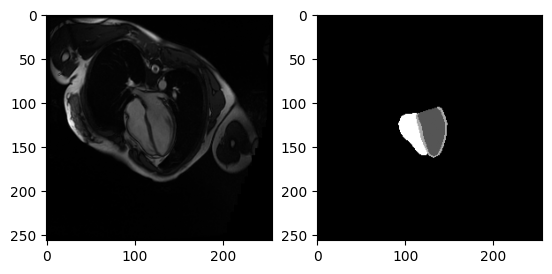

In [22]:
# Show an example of MRI and manual annotation
example_img = nib.load("./cardiac segmentation/compiled/images/001_LA_ED_001.nii.gz").get_fdata()
example_label = nib.load("./cardiac segmentation/compiled/labels/001_LA_ED_gt_001.nii.gz").get_fdata()

plt.subplot(1,2,1)
plt.imshow(example_img, cmap='gray')

plt.subplot(1,2,2)
plt.imshow(example_label, cmap='gray')
plt.show()

In [28]:
# ========= Training the Model =========
# Define the optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

loss_fn = torch.nn.CrossEntropyLoss()

# Circuit training and validation
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_correct = 0
    total_pixels = 0

    # Train
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training]"):
        imgs, labels = imgs.to(device).contiguous(), labels.to(device).contiguous()

        outputs = model(pixel_values=imgs)
        logits = outputs.logits

        # Resize labels to match logits if needed
        labels_down = F.interpolate(
            labels.unsqueeze(1).float(), 
            size=logits.shape[2:], 
            mode='nearest'
        ).squeeze(1).long()

        loss = loss_fn(
            logits.contiguous(),
            labels_down.contiguous())
        loss.backward()
        
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        # Compute accuracy
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == labels_down).sum().item()
        total_pixels += torch.numel(labels_down)

    train_loss = total_loss / len(train_loader)
    train_acc = total_correct / total_pixels

    # Validate
    model.eval()
    val_loss = 0
    val_correct = 0
    val_pixels = 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"[Epoch {epoch+1}/{num_epochs} Validation]"):
            imgs, labels = imgs.to(device).contiguous(), labels.to(device).contiguous()

            outputs = model(pixel_values=imgs)
            logits = outputs.logits
            labels_down = F.interpolate(labels.unsqueeze(1).float(), size=logits.shape[2:], mode='nearest').squeeze(1).long()

            loss = loss_fn(logits, labels_down)
            val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels_down).sum().item()
            val_pixels += torch.numel(labels_down)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_pixels

    print(f"[Epoch {epoch+1}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

# Save the model
torch.save(model.state_dict(), "./segformer_cardiac.pth")

[Epoch 1/10 Validation]: 100%|██████████| 187/187 [01:21<00:00,  2.28it/s]


[Epoch 1] Train Loss: 0.5073, Train Acc: 91.21%, Val Loss: 0.1402, Val Acc: 98.08%


[Epoch 2/10 Validation]: 100%|██████████| 187/187 [01:24<00:00,  2.21it/s]


[Epoch 2] Train Loss: 0.1033, Train Acc: 98.30%, Val Loss: 0.0673, Val Acc: 98.65%


[Epoch 3/10 Validation]: 100%|██████████| 187/187 [01:23<00:00,  2.23it/s]


...

[Epoch 8] Train Loss: 0.0169, Train Acc: 99.49%, Val Loss: 0.0175, Val Acc: 99.44%


[Epoch 9/10 Validation]: 100%|██████████| 187/187 [01:24<00:00,  2.20it/s]


[Epoch 9] Train Loss: 0.0147, Train Acc: 99.53%, Val Loss: 0.0159, Val Acc: 99.47%


[Epoch 10/10 Validation]: 100%|██████████| 187/187 [01:25<00:00,  2.19it/s]

[Epoch 10] Train Loss: 0.0133, Train Acc: 99.56%, Val Loss: 0.0155, Val Acc: 99.48%


In [8]:
# ========= Segmentation Model Inference =========
# Set the path
image_dir = "./cardiac segmentation/compiled/images"
save_dir = "./cardiac segmentation/segmentation_output"
os.makedirs(save_dir, exist_ok=True)

# Set the device (MPS / CUDA / CPU)
# The inference part is not effect
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# If you only start from the inference stage, uncomment below part to load the SegFormer model
# num_classes = 4
# model = SegformerForSemanticSegmentation.from_pretrained(
#     "nvidia/segformer-b0-finetuned-ade-512-512",
#     num_labels=num_classes,
#     ignore_mismatched_sizes=True
# )

# Load offline parameter file and run the model
model.load_state_dict(torch.load("./segformer_cardiac.pth", map_location=device))
model.to(device)
model.eval()

# Load a feature extractor (with standard normalization)
feature_extractor = SegformerFeatureExtractor(do_resize=True, size=256, resample=3, do_normalize=True)

# Circular inference
for fname in sorted(os.listdir(image_dir)):
    if not fname.endswith(".nii.gz"):
        continue

    img_path = os.path.join(image_dir, fname)
    base_name = fname.replace(".nii.gz", "")

    # Read original image
    img_data = nib.load(img_path).get_fdata().astype(np.float32)

    # Normalize and process to RGB (pretending to be three channels)
    img = np.clip(img_data, 0, np.percentile(img_data, 99))
    img = (img - img.min()) / (img.max() - img.min() + 1e-5) * 255.0
    img = img.astype(np.uint8)
    img_rgb = np.repeat(np.expand_dims(img, axis=2), 3, axis=2)

    # Preprocess and infer
    processed = feature_extractor(images=img_rgb, return_tensors="pt")
    pixel_values = processed["pixel_values"].to(device)

    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)
        logits = outputs.logits                                         # shape: (1, 4, H, W)
        preds = torch.argmax(logits, dim=1).squeeze().cpu().numpy()     # shape: (H, W)

    # Construct three foreground masks
    masks = [(preds == cls_id).astype(np.uint8) * 255 for cls_id in [1, 2, 3]]

    # Save original image size
    H_orig, W_orig = img.shape

    # Restore original image size
    masks_resized = [F.interpolate(torch.tensor(mask).unsqueeze(0).unsqueeze(0).float(), size=(H_orig, W_orig), mode='nearest').squeeze().byte().numpy() for mask in masks]

    # Cut out the segmented area from the original image
    cutouts = [(img * (mask > 0)).astype(np.uint8) for mask in masks_resized]

    # Splice into horizontal picture
    concat_img = np.concatenate(cutouts, axis=1)

    # Save as .npy file
    save_path = os.path.join(save_dir, f"{base_name}_seg_concat.npy")
    np.save(save_path, concat_img)
    print(f"Saved: {save_path}")

Using device: mps


/opt/miniconda3/envs/rv-segmentation/lib/python3.10/site-packages/transformers/models/segformer/feature_extraction_segformer.py:30: FutureWarning: The class SegformerFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use SegformerImageProcessor instead.
  warnings.warn(


Saved: ./cardiac segmentation/segmentation_output/001_LA_ED_001_seg_concat.npy
Saved: ./cardiac segmentation/segmentation_output/001_LA_ES_001_seg_concat.npy
Saved: ./cardiac segmentation/segmentation_output/001_SA_ED_003_seg_concat.npy
Saved: ./cardiac segmentation/segmentation_output/001_SA_ED_004_seg_concat.npy
Saved: ./cardiac segmentation/segmentation_output/001_SA_ED_005_seg_concat.npy
Saved: ./cardiac segmentation/segmentation_output/001_SA_ED_006_seg_concat.npy
Saved: ./cardiac segmentation/segmentation_output/001_SA_ED_007_seg_concat.npy
Saved: ./cardiac segmentation/segmentation_output/001_SA_ED_008_seg_concat.npy
Saved: ./cardiac segmentation/segmentation_output/001_SA_ED_009_seg_concat.npy
Saved: ./cardiac segmentation/segmentation_output/001_SA_ED_010_seg_concat.npy
Saved: ./cardiac segmentation/segmentation_output/001_SA_ED_011_seg_concat.npy
Saved: ./cardiac segmentation/segmentation_output/001_SA_ES_005_seg_concat.npy
Saved: ./cardiac segmentation/segmentation_output/00

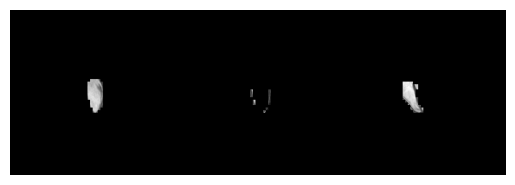

In [13]:
# Show an example of segmentation
example = np.load("./cardiac segmentation/segmentation_output/001_LA_ED_001_seg_concat.npy")
plt.imshow(example, cmap='gray')
plt.axis('off')
plt.show()

## MRI Pathology Classification after Segmentation

In [13]:
# ========= Loading Data and Model =========
# Set the path
data_csv = "./cardiac segmentation/dataset_information.csv"
npy_dir = "./cardiac segmentation/segmentation_output"

# Map labels
info_df = pd.read_csv(data_csv)
info_df = info_df.dropna(subset=["SUBJECT_CODE"])
info_df["SUBJECT_CODE"] = info_df["SUBJECT_CODE"].astype(float).astype(int).astype(str).str.zfill(3)
code2disease = dict(zip(info_df["SUBJECT_CODE"], info_df["DISEASE"]))

# Prepare the data
data = []
labels = []

for fname in sorted(os.listdir(npy_dir)):
    if not fname.endswith(".npy"):
        continue
    subject_id = fname[:3]
    if subject_id in code2disease:
        data.append(os.path.join(npy_dir, fname))
        labels.append(code2disease[subject_id])

# Encode the labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)

# Load a feature extractor
feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224")

# Load a image enhancer
transform = transforms.Compose([
    transforms.Resize((224, 224)),                      # ViT input resolution
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),   # (1, H, W) → (3, H, W)
    transforms.Normalize(mean=feature_extractor.image_mean, std=feature_extractor.image_std)
])

# Define dataset subclasses based on actual data conditions
class MRIDataset(Dataset):

    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        arr = np.load(self.paths[idx])
        img = torch.tensor(arr, dtype=torch.float32).unsqueeze(0) / 255.0
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return {"pixel_values": img, "label": label}
    
# Split training and validation sets
train_paths, val_paths, train_labels, val_labels = train_test_split(data, encoded_labels, test_size=0.3, random_state=42)

train_dataset = MRIDataset(train_paths, train_labels, transform)
val_dataset = MRIDataset(val_paths, val_labels, transform)

# Load the ViT model
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)

model.config.problem_type = "single_label_classification"

/var/folders/b0/_kzmybgx3rz83p6zk4_xk1xh0000gn/T/ipykernel_98029/982420525.py:7: DtypeWarning: Columns (1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  info_df = pd.read_csv(data_csv)
/opt/miniconda3/envs/rv-segmentation/lib/python3.10/site-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(
Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use 

In [ ]:
# ========= Training the Model =========
# Set training parameters
training_args = TrainingArguments(
    output_dir="./",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=10,
    learning_rate=5e-5,
    logging_dir="./logs",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

# Load the evaluator and define the evaluation
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return accuracy.compute(predictions=preds, references=labels)

# Configure the trainer and train
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    tokenizer=feature_extractor,
)

trainer.train()

/var/folders/b0/_kzmybgx3rz83p6zk4_xk1xh0000gn/T/ipykernel_98029/1940163408.py:26: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/opt/miniconda3/envs/rv-segmentation/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.601400,0.650581,0.613423
2,0.448300,0.519872,0.738255
3,0.408800,0.574351,0.754362
4,0.389200,0.610483,0.800000
5,0.370600,0.772656,0.791946
6,0.149500,0.944763,0.797315
7,0.031900,1.302277,0.783893
8,0.025500,1.533095,0.770470
9,0.002100,1.398181,0.789262
10,0.000000,1.417051,0.787919


/opt/miniconda3/envs/rv-segmentation/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/miniconda3/envs/rv-segmentation/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/miniconda3/envs/rv-segmentation/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt/miniconda3/envs/rv-segmentation/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/opt

TrainOutput(global_step=2170, training_loss=0.2115454650012329, metrics={'train_runtime': 683.6183, 'train_samples_per_second': 25.394, 'train_steps_per_second': 3.174, 'total_flos': 1.345260939709317e+18, 'train_loss': 0.2115454650012329, 'epoch': 10.0})

## Reference

- *M&Ms-2 Challenge*. (n.d.). Www.ub.edu. https://www.ub.edu/mnms-2/.
- Linardos, A., Kushibar, K., Walsh, S., Gkontra, P., & Lekadir, K. (2022). Federated learning for multi-center imaging diagnostics: a simulation study in cardiovascular disease. *Scientific Reports*, 12(1). https://doi.org/10.1038/s41598-022-07186-4.
- SegFormer. (n.d.). Huggingface.co. https://huggingface.co/docs/transformers/model_doc/segformer.
- Vision Transformer (ViT). (n.d.). Huggingface.co. https://huggingface.co/docs/transformers/model_doc/vit.
‌

**End of the Notebook**